In [1]:
!pip install -r ../requirements.txt

In [2]:
import torch
print(torch.version.cuda)
print(torch.cuda.is_available())

12.8
True


In [3]:
import sys
import importlib
sys.path.append("..")

# Import your modules first
import helper
import obelix
import algorithms.updated_p3_sub6_fixed as d3qn_per_agent
import configurations.config_p3_sub6 as config

# Reload them to pick up any changes
importlib.reload(helper)
importlib.reload(obelix)
importlib.reload(d3qn_per_agent)
importlib.reload(config)

device used:  cuda
device used:  cuda


<module 'configurations.config_p3_sub6' from 'c:\\Users\\hgoel\\MTech_Resources\\DRL\\Capstone_Project\\CS780-OBELIX\\run_scripts\\..\\configurations\\config_p3_sub6.py'>

In [4]:
from helper import plotQuantity
from obelix import OBELIX
from algorithms.updated_p3_sub6_fixed import D3QN_PER
from configurations.config_p3_sub6 import config

In [5]:
config['model_path'] = "../model_weights/model_weights_eval_p3_sub6_fixed_last"
config["noise_std"] = 0.2
config["eta"] = 0.08
config['eps_decay_strategy'] = [
        ("linear", {'s': 0, 'e': 499, 'ival': 1.0, 'fval': 0.25}),
        ("exponential", {'s': 500, 'e': 999, 'ival': 0.28, 'fval': 0.01})
    ]
config['MAX_TRAIN_EPISODES'] = 1000
print(config)

{'seed': 333, 'gamma': 0.99, 'bufferSize': 1000000, 'batchSize': 32, 'optimizerFn': <class 'torch.optim.adam.Adam'>, 'optimizerLR': 0.0001, 'MAX_TRAIN_EPISODES': 1000, 'MAX_EVAL_EPISODES': 5, 'updateFrequency': 80, 'explorationStrategyTrainFn': <function selectEpsilonGreedyActionREP_NOISY at 0x0000020381F09620>, 'explorationStrategyEvalFn': <function selectGreedyActionREP_COMP at 0x0000020381F094E0>, 'max_steps': 1000, 'epsilon': 0.98, 'eps_decay_strategy': [('linear', {'s': 0, 'e': 499, 'ival': 1.0, 'fval': 0.25}), ('exponential', {'s': 500, 'e': 999, 'ival': 0.28, 'fval': 0.01})], 'device': device(type='cuda'), 'delta': 0.99, 'tau': 0.005, 'alpha': 0.58, 'beta': 0.42, 'beta_rate': 0.0002, 'f_hDim': [324, 256], 'lstm_hDim': 128, 'model_path': '../model_weights/model_weights_eval_p3_sub6_fixed_last', 'loss_fn': 'HuberLoss', 'seq_len': 30, 'burn_in': 10, 'minSamples': 40, 'for_hDim': [224, 128], 'inv_hDim': [224, 128], 'alpha_f': 0.12, 'beta_i': 0.15, 'eta': 0.08, 'noise_std': 0.2}


In [6]:
env1 = OBELIX(
    scaling_factor=5,
    arena_size=500,
    max_steps=1000,
    wall_obstacles=True,
    difficulty=3,
    box_speed=4,
)

env2 = OBELIX(
    scaling_factor=5,
    arena_size=500,
    max_steps=1000,
    wall_obstacles=False,
    difficulty=3,
    box_speed=4,
)

D3QN_PER_LSTM_with_REP_BAD_HEAD_Agent = D3QN_PER(env1, env2, config)

In [7]:
d3qnPerTrainRewardsList, d3qnPerTrainTimeList, d3qnPerEvalRewardsList1, d3qnPerEvalRewardsList2, d3qnPerWallClockTimeList, d3qnPerTotalStepsList = D3QN_PER_LSTM_with_REP_BAD_HEAD_Agent.runD3QN_PER()

Episode 1: TR(without walls) -15068.000 | TT 8.791 | TS 1000
Episode 2: TR(without walls) -531.000 | TT 9.207 | TS 54
Episode 3: TR(with walls) -39268.000 | TT 16.884 | TS 1000
Episode 4: TR(without walls) -28373.000 | TT 24.427 | TS 1000
Episode 5: TR(with walls) -14460.000 | TT 29.234 | TS 589
Episode 6: TR(without walls) -72393.000 | TT 42.778 | TS 1000
Episode 7: TR(without walls) -2069.000 | TT 56.516 | TS 1000
Episode 8: TR(without walls) -3510.000 | TT 59.578 | TS 240
Episode 9: TR(without walls) -42978.000 | TT 68.891 | TS 706
Episode 10: TR(with walls) -3034.000 | TT 71.207 | TS 166
Episode 11: TR(without walls) -59596.000 | TT 84.621 | TS 1000
Episode 12: TR(with walls) -62480.000 | TT 98.694 | TS 1000
Episode 13: TR(without walls) -2487.000 | TT 112.231 | TS 1000
Episode 14: TR(with walls) -32781.000 | TT 125.594 | TS 1000
Episode 15: TR(without walls) -30679.000 | TT 139.450 | TS 1000
Episode 16: TR(with walls) -38175.000 | TT 152.901 | TS 1000
Episode 17: TR(without walls)

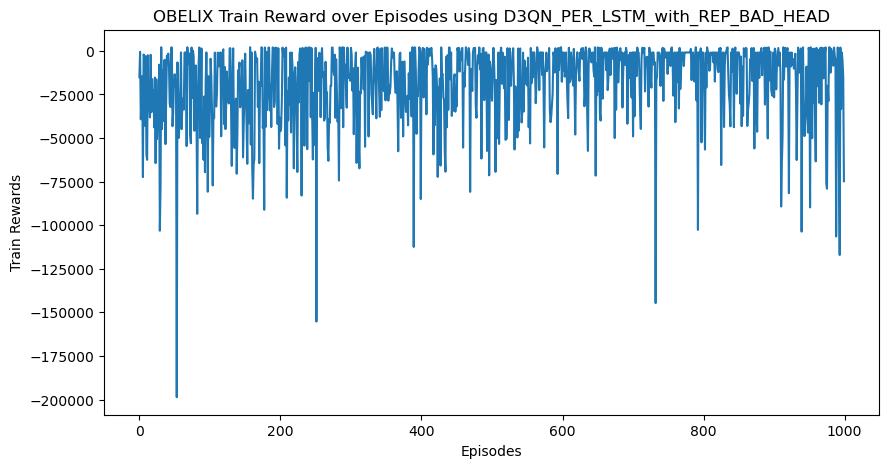

In [8]:
plotQuantity(
    d3qnPerTrainRewardsList,
    len(d3qnPerTrainRewardsList),
    descriptionList = ["Episodes", "Train Rewards", "OBELIX Train Reward over Episodes using D3QN_PER_LSTM_with_REP_BAD_HEAD"] 
)

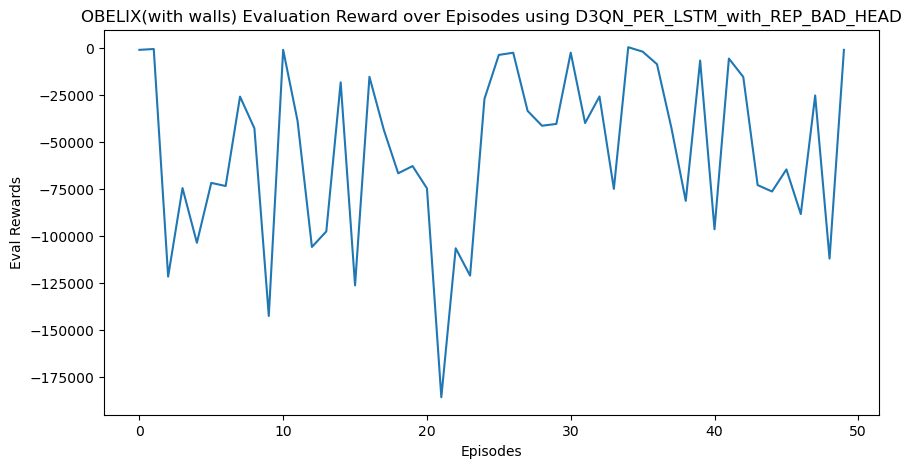

In [9]:
plotQuantity(
    d3qnPerEvalRewardsList1, 
    len(d3qnPerEvalRewardsList1), 
    descriptionList = ["Episodes", "Eval Rewards", "OBELIX(with walls) Evaluation Reward over Episodes using D3QN_PER_LSTM_with_REP_BAD_HEAD"]    
)

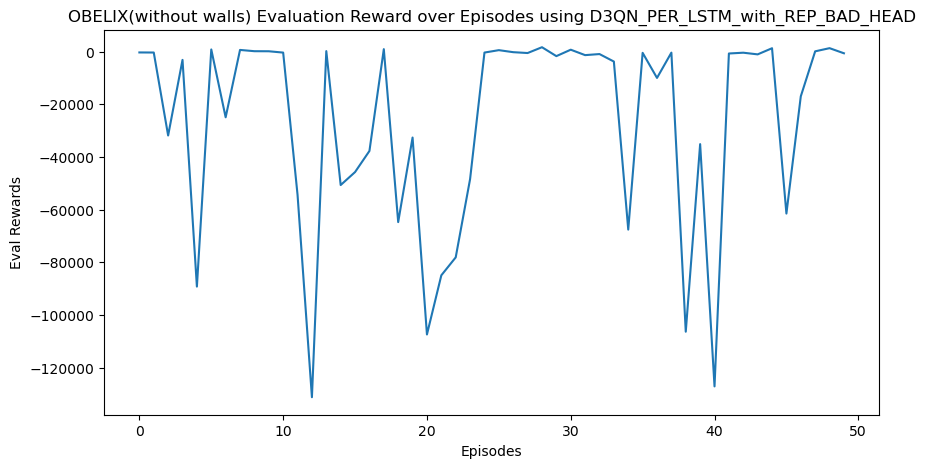

In [10]:
plotQuantity(
    d3qnPerEvalRewardsList2, 
    len(d3qnPerEvalRewardsList2), 
    descriptionList = ["Episodes", "Eval Rewards", "OBELIX(without walls) Evaluation Reward over Episodes using D3QN_PER_LSTM_with_REP_BAD_HEAD"]    
)

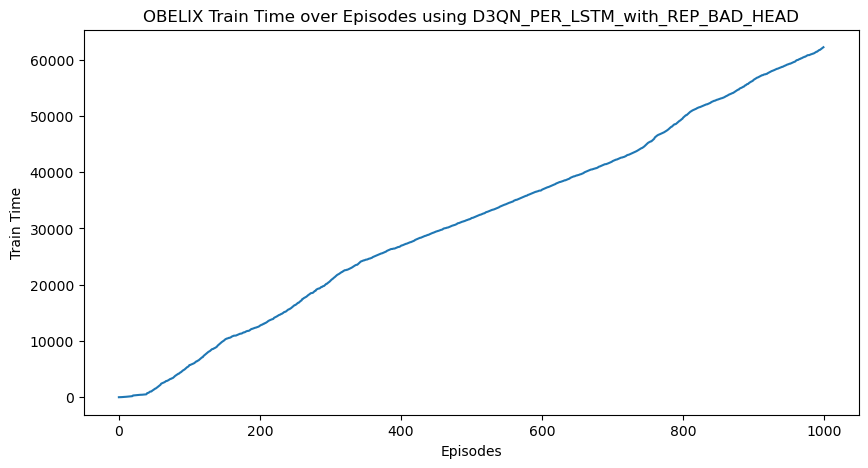

In [11]:
plotQuantity(
    d3qnPerTrainTimeList, 
    len(d3qnPerTrainTimeList), 
    descriptionList = ["Episodes", "Train Time", "OBELIX Train Time over Episodes using D3QN_PER_LSTM_with_REP_BAD_HEAD"]    
)

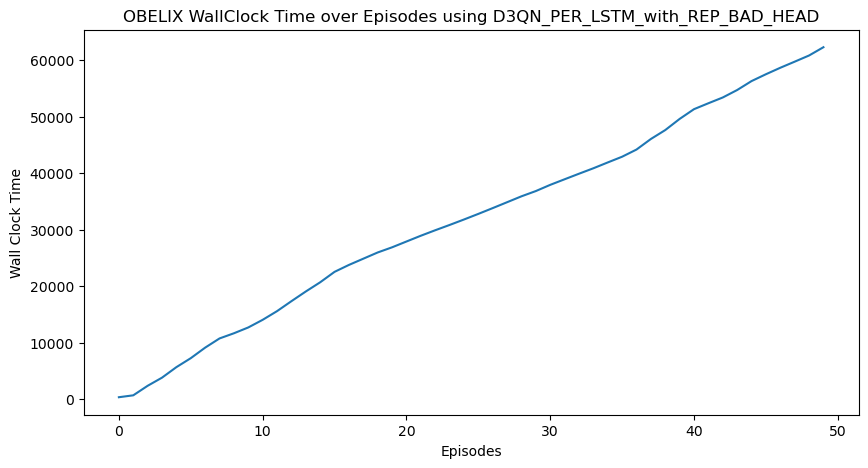

In [12]:
plotQuantity(
    d3qnPerWallClockTimeList, 
    len(d3qnPerWallClockTimeList), 
    descriptionList = ["Episodes", "Wall Clock Time", "OBELIX WallClock Time over Episodes using D3QN_PER_LSTM_with_REP_BAD_HEAD"]    
)

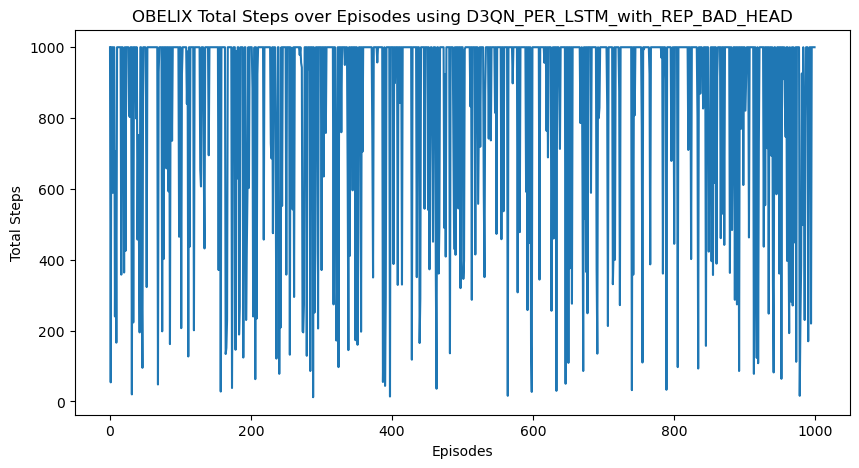

In [13]:
plotQuantity(
    d3qnPerTotalStepsList, 
    len(d3qnPerTotalStepsList), 
    descriptionList = ["Episodes", "Total Steps", "OBELIX Total Steps over Episodes using D3QN_PER_LSTM_with_REP_BAD_HEAD"]    
)

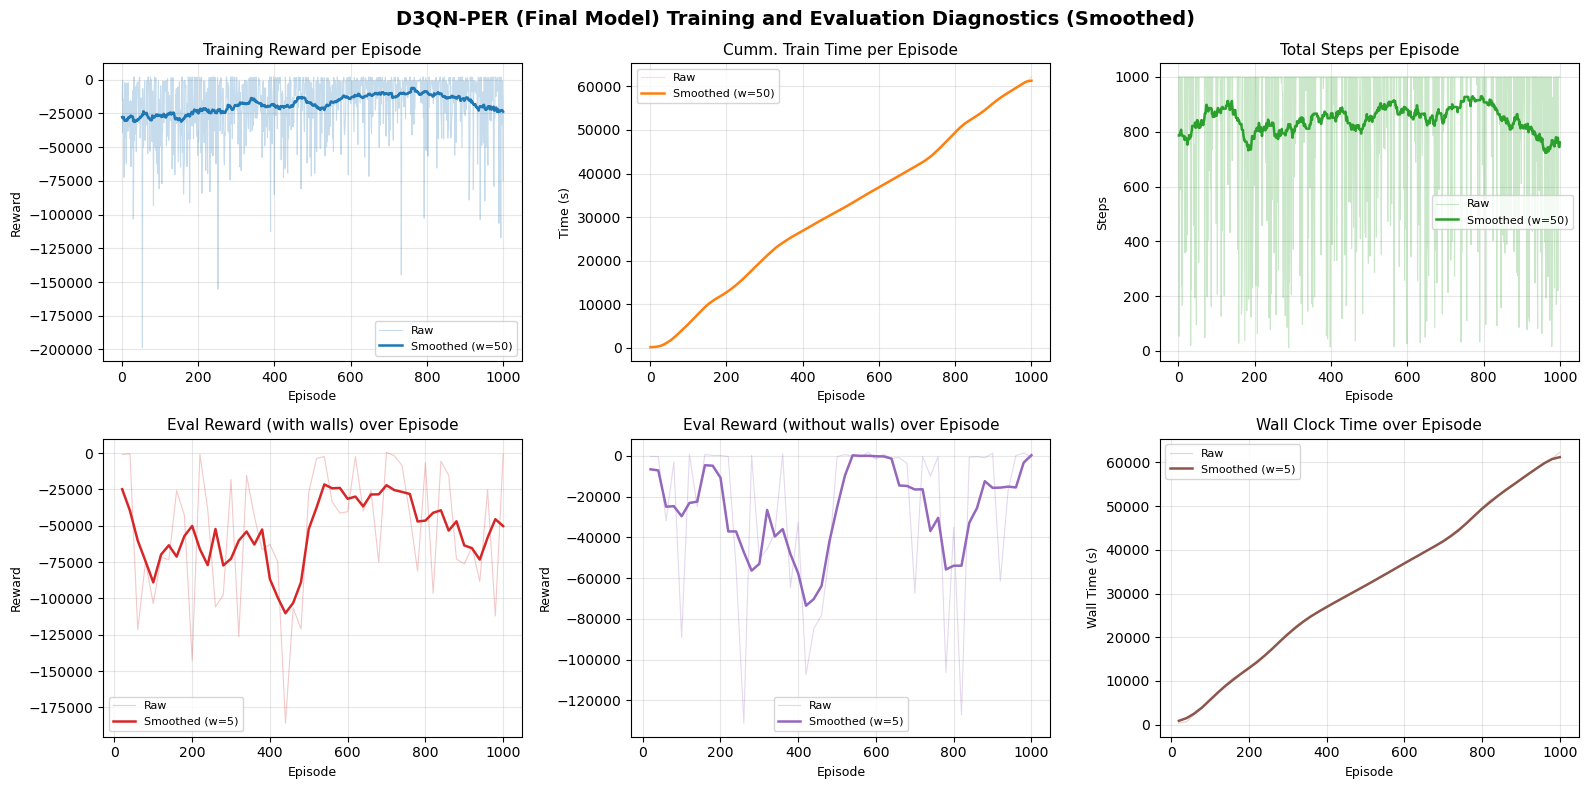

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import uniform_filter1d

def smooth(data, window=10):
    return uniform_filter1d(data, size=window)

# ── episode axes ──────────────────────────────────────────────
train_eps  = np.arange(1, len(d3qnPerTrainRewardsList) + 1)
eval_eps   = np.arange(20, 20 * len(d3qnPerEvalRewardsList1) + 1, 20)

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
fig.suptitle("D3QN-PER (Final Model) Training and Evaluation Diagnostics (Smoothed)", fontsize=14, fontweight='bold')

plots = [
    (axes[0, 0], train_eps, d3qnPerTrainRewardsList,  "Training Reward per Episode",        "Episode", "Reward",         "tab:blue"),
    (axes[0, 1], train_eps, d3qnPerTrainTimeList,      "Cumm. Train Time per Episode", "Episode", "Time (s)",       "tab:orange"),
    (axes[0, 2], train_eps, d3qnPerTotalStepsList,     "Total Steps per Episode",            "Episode", "Steps",          "tab:green"),
    (axes[1, 0], eval_eps,  d3qnPerEvalRewardsList1,   "Eval Reward (with walls) over Episode", "Episode", "Reward",         "tab:red"),
    (axes[1, 1], eval_eps,  d3qnPerEvalRewardsList2,   "Eval Reward (without walls) over Episode", "Episode", "Reward",         "tab:purple"),
    (axes[1, 2], eval_eps,  d3qnPerWallClockTimeList,  "Wall Clock Time over Episode",        "Episode", "Wall Time (s)",  "tab:brown"),
]

for ax, x, raw, title, xlabel, ylabel, color in plots:
    raw_arr = np.array(raw)
    win     = max(5, len(raw_arr) // 20)          # adaptive window
    sm      = smooth(raw_arr, window=win)

    ax.plot(x, raw_arr, alpha=0.25, color=color, linewidth=0.8, label="Raw")
    ax.plot(x, sm,      color=color, linewidth=1.8, label=f"Smoothed (w={win})")
    ax.set_title(title, fontsize=11)
    ax.set_xlabel(xlabel, fontsize=9)
    ax.set_ylabel(ylabel, fontsize=9)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("d3qn_per_diagnostics.png", dpi=150, bbox_inches='tight')
plt.show()